# AdaBoost Classifier Implementation

This notebook demonstrates a step-by-step implementation of the AdaBoost algorithm using Decision Tree Stumps as weak learners.

## Step 1: Import Required Libraries

In [1]:
# Import the necessary libraries for the programme
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions

## Step 2: Create Dummy Dataset
Create a simple dataset for demonstration purposes with 2 features (x1, x2) and a binary target (y).

In [2]:
# Dummy Dataset for our Analysis
df = pd.DataFrame(
    {
        'x1' :  [5,2,1,9,3],
        'x2' :  [7,9,3,8,7],
        'y'  :  [1,0,1,0,0]
    }   
)

## Step 3: Visualize the Dataset
Plot the data points to understand their distribution in the feature space.

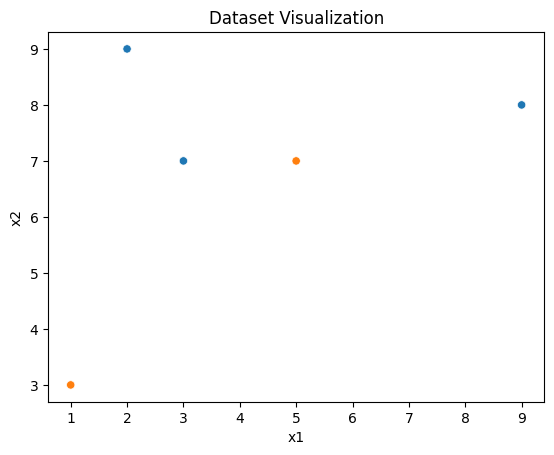

In [3]:
# Plotting the points
sns.scatterplot(    
    data = df,
    x = 'x1',
    y = 'x2',
    hue = 'y',
    legend = False
)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Dataset Visualization')
plt.show()

## Step 4: Display the Dataset

In [4]:
df

,x1,x2,y
0,5,7,1
1,2,9,0
2,1,3,1
3,9,8,0
4,3,7,0


## Step 5: Initialize Sample Weights
Initialize equal weights for all data points (1/n where n is the number of samples).

In [5]:
# Weights = 1/len(df) or No of rows
df['weights'] = 1/len(df)
df

,x1,x2,y,weights
0,5,7,1,0.2
1,2,9,0,0.2
2,1,3,1,0.2
3,9,8,0,0.2
4,3,7,0,0.2


## Step 6: Prepare Features and Target
Separate features (X) and target variable (y).

In [6]:
X, y = df.iloc[:,:2].values, df.iloc[:,-2].values

## Step 7: Create First Weak Learner (Decision Tree Stump)
Create a decision tree with max_depth=1, which acts as a stump - the simplest possible tree.

In [7]:
# Now I will create a weak learner Decision Tree model with max_depth = 1 that will act as a stump.
dtr1 = DecisionTreeClassifier(max_depth=1)
dtr1.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

## Step 8: Make Predictions with First Weak Learner

In [8]:
df['y_pred'] = dtr1.predict(X)

## Step 9: Visualize the Decision Tree Stump
Plot the decision tree to understand how it makes decisions.

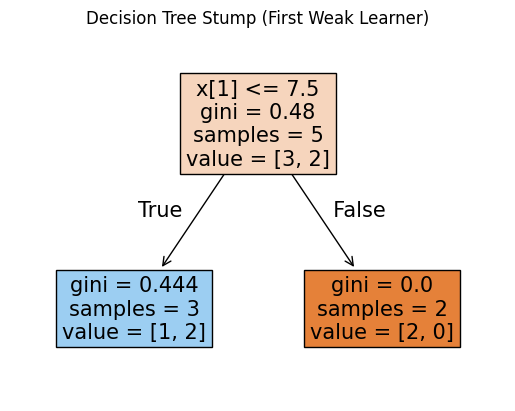

In [9]:
# Plot the tree to Understand what's going on Inside
plot_tree(
    dtr1,
    filled = True,
    fontsize = 15
)
plt.title('Decision Tree Stump (First Weak Learner)')
plt.show()

## Step 10: Display Current Predictions and Weights

In [10]:
df

,x1,x2,y,weights,y_pred
0,5,7,1,0.2,1
1,2,9,0,0.2,0
2,1,3,1,0.2,1
3,9,8,0,0.2,0
4,3,7,0,0.2,1


## Step 11: Visualize Decision Boundaries
Plot the decision regions to see how the stump classifies the data.

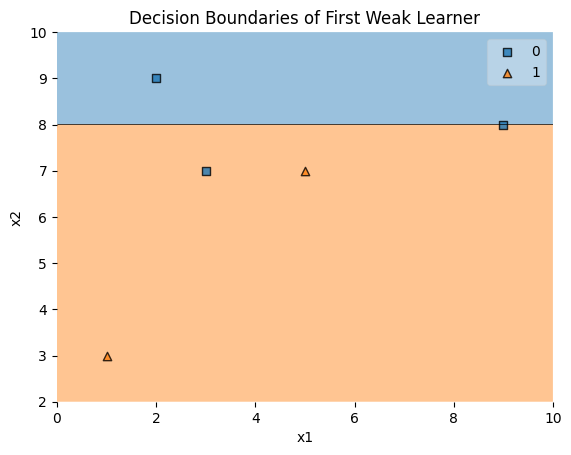

In [11]:
plot_decision_regions(
    X,
    y,
    dtr1
)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Decision Boundaries of First Weak Learner')
plt.show()

## Step 12: Calculate Model Weight (Alpha)

Calculate the weight of this weak learner in the final ensemble based on its error rate.

The formula is: α = 0.5 * ln((1 - error) / error)
Where error is the sum of weights of misclassified points.

In [12]:
# Missclassified points: (3,7) with weight 0.2
# Model Weight: alpha1 = 0.5 * ln((1 - sum_of_error_weights)/(sum_of_error_weights))
eta = 1e-10  # To avoid alpha from getting zero when the model fully classifies
alpha1 = 0.5 * np.log((1 - (0.2 + eta)) / (0.2 + eta))  # 0.2 is the weight of misclassified point (3,7)

## Step 13: Update Sample Weights
Update weights based on classification performance:
- Decrease weights of correctly classified points
- Increase weights of incorrectly classified points

Formula:
- Correctly classified: new_weight = current_weight * e^(-α)
- Incorrectly classified: new_weight = current_weight * e^(α)

In [13]:
df['updated_weights'] = np.where(
    df['y'] == df['y_pred'],  # The condition
    df['weights'] * (np.e ** (-alpha1)),  # Correctly classified
    df['weights'] * (np.e ** (alpha1))   # Incorrectly classified
)
df

,x1,x2,y,weights,y_pred,updated_weights
0,5,7,1,0.2,1,0.1
1,2,9,0,0.2,0,0.1
2,1,3,1,0.2,1,0.1
3,9,8,0,0.2,0,0.1
4,3,7,0,0.2,1,0.4


## Step 14: Normalize Updated Weights
Normalize weights so they sum to 1, creating a probability distribution for sampling.

In [14]:
# Now we will normalize these new_weights
# normalized_weights = updated_weights / sum(updated_weights)
# Why Normalized? We want the weights to follow a normal distribution between range 0 and 1.
# We will use this range for further creation of range and random values
df['normalized_weights'] = df['updated_weights'] / np.sum(df['updated_weights'])
df

,x1,x2,y,weights,y_pred,updated_weights,normalized_weights
0,5,7,1,0.2,1,0.1,0.125
1,2,9,0,0.2,0,0.1,0.125
2,1,3,1,0.2,1,0.1,0.125
3,9,8,0,0.2,0,0.1,0.125
4,3,7,0,0.2,1,0.4,0.500


## Step 15: Create Sampling Ranges
Create cumulative probability ranges for each data point. These ranges will be used for weighted sampling in the next iteration.

In [15]:
# Now we will create a range of values where:
# range_start of i = range_end of i-1 
# range_end of i = range_start + normalized_weight for that i
# (for i = 1, range_start = 0.000 and range_end = normalized_weight)
# Basically the cumulative sum of normalized_weights
df['range_end'] = np.cumsum(df['normalized_weights'])
df['range_start'] = df['range_end'] - df['normalized_weights']
df

,x1,x2,y,weights,y_pred,updated_weights,normalized_weights,range_end,range_start
0,5,7,1,0.2,1,0.1,0.125,0.125,0.000
1,2,9,0,0.2,0,0.1,0.125,0.250,0.125
2,1,3,1,0.2,1,0.1,0.125,0.375,0.250
3,9,8,0,0.2,0,0.1,0.125,0.500,0.375
4,3,7,0,0.2,1,0.4,0.500,1.000,0.500


## Step 16: Perform Weighted Sampling for Next Iteration

Now we'll create a new dataset by sampling points based on their normalized weights. Points with higher weights (misclassified in previous iteration) have a higher chance of being selected.

In [16]:
# Generate random numbers between 0 and 1 for sampling
np.random.seed(42)  # For reproducibility
random_numbers = np.random.rand(len(df))

# Create a function to find which range each random number falls into
def find_selected_point(random_num):
    for i in range(len(df)):
        if df['range_start'].iloc[i] <= random_num < df['range_end'].iloc[i]:
            return i
    return len(df) - 1  # Fallback for edge case

# Create new indices based on weighted sampling
new_indices = [find_selected_point(r) for r in random_numbers]

# Create new dataset based on weighted sampling
df_sampled = df.iloc[new_indices].reset_index(drop=True)

print("Original dataset indices:", list(range(len(df))))
print("Random numbers for sampling:", random_numbers)
print("Selected indices from sampling:", new_indices)
print("\nSampled dataset:")
df_sampled[['x1', 'x2', 'y']]

Original dataset indices: [0, 1, 2, 3, 4]
Random numbers for sampling: [0.37454012 0.95071431 0.73199394 0.59865848 0.15601864]
Selected indices from sampling: [2, 4, 4, 4, 1]

Sampled dataset:


,x1,x2,y
0,1,3,1
1,3,7,0
2,3,7,0
3,3,7,0
4,2,9,0


## Step 17: Train Second Weak Learner

Train a new decision tree stump on the sampled dataset. Note that some points may appear multiple times in the sampled dataset due to weighted sampling.

In [17]:
# Extract features and target from sampled dataset
X_sampled = df_sampled[['x1', 'x2']].values
y_sampled = df_sampled['y'].values

# Create and train second weak learner
dtr2 = DecisionTreeClassifier(max_depth=1)
dtr2.fit(X_sampled, y_sampled)

# Add predictions to original dataframe for comparison
df['y_pred2'] = dtr2.predict(X)

## Step 18: Visualize Second Weak Learner

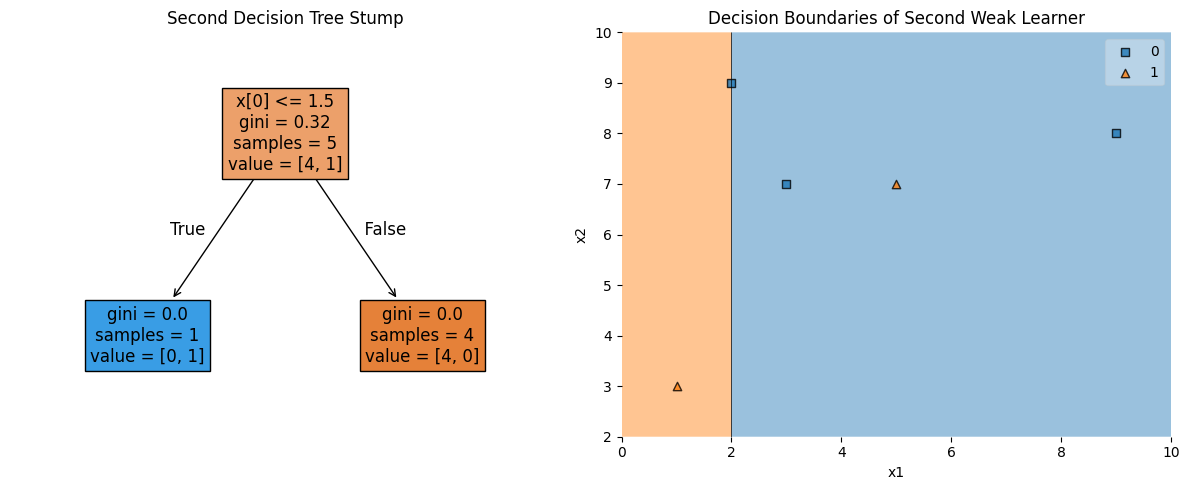

In [18]:
# Plot the second decision tree
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plot_tree(
    dtr2,
    filled=True,
    fontsize=12
)
plt.title('Second Decision Tree Stump')

plt.subplot(1, 2, 2)
plot_decision_regions(
    X,
    y,
    dtr2
)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Decision Boundaries of Second Weak Learner')

plt.tight_layout()
plt.show()

## Step 19: Calculate Error and Alpha for Second Weak Learner

Calculate the weighted error rate and the model weight (alpha) for the second weak learner.

In [19]:
# Calculate misclassified points using current weights (normalized_weights)
# Note: We use df (original) for calculating error as we need to evaluate on original distribution

# Identify misclassified points
misclassified_mask = df['y'] != df['y_pred2']
misclassified_indices = df[misclassified_mask].index.tolist()

# Calculate weighted error
weighted_error = df.loc[misclassified_mask, 'normalized_weights'].sum()

print(f"Misclassified points indices: {misclassified_indices}")
print(f"Weighted error for second weak learner: {weighted_error:.4f}")

# Calculate alpha for second weak learner
alpha2 = 0.5 * np.log((1 - weighted_error + eta) / (weighted_error + eta))
print(f"Alpha (weight) for second weak learner: {alpha2:.4f}")

Misclassified points indices: [0]
Weighted error for second weak learner: 0.1250
Alpha (weight) for second weak learner: 0.9730


## Step 20: Update Weights for Next Iteration

Update weights based on the performance of the second weak learner.

In [20]:
# Update weights based on second weak learner's predictions
df['updated_weights2'] = np.where(
    df['y'] == df['y_pred2'],  # Correctly classified
    df['normalized_weights'] * (np.e ** (-alpha2)),  # Decrease weight
    df['normalized_weights'] * (np.e ** (alpha2))    # Increase weight
)

# Normalize the new weights
df['normalized_weights2'] = df['updated_weights2'] / np.sum(df['updated_weights2'])

# Update ranges for next sampling
df['range_end2'] = np.cumsum(df['normalized_weights2'])
df['range_start2'] = df['range_end2'] - df['normalized_weights2']

print("Updated weights after second iteration:")
df[['x1', 'x2', 'y', 'normalized_weights', 'y_pred2', 'normalized_weights2']]

Updated weights after second iteration:


,x1,x2,y,normalized_weights,y_pred2,normalized_weights2
0,5,7,1,0.125,0,0.500000
1,2,9,0,0.125,0,0.071429
2,1,3,1,0.125,1,0.071429
3,9,8,0,0.125,0,0.071429
4,3,7,0,0.500,0,0.285714


## Step 21: Visualize Weight Evolution

Let's visualize how weights change across iterations for each data point.

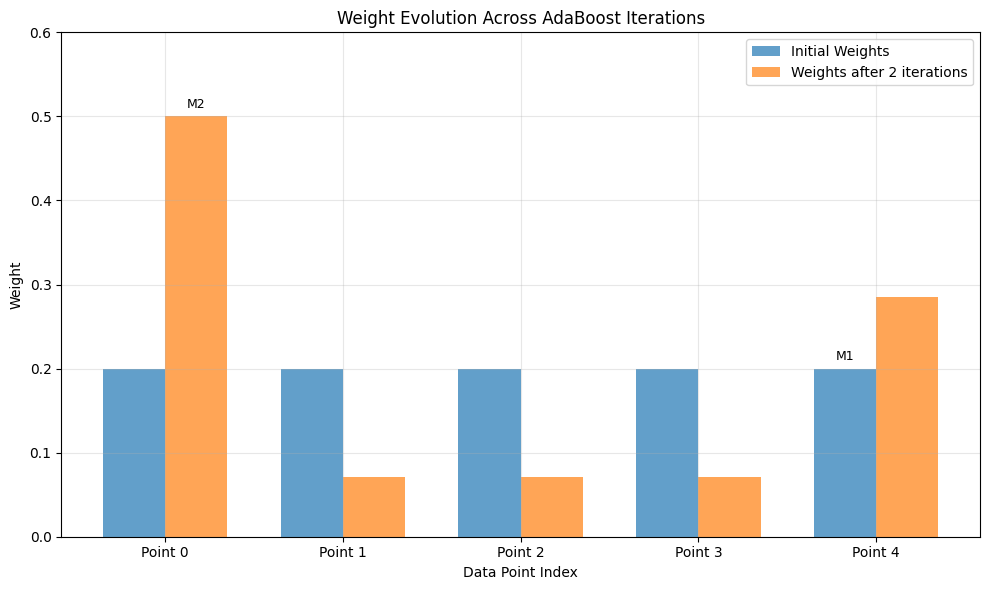

In [21]:
# Create a visualization of weight evolution
plt.figure(figsize=(10, 6))
x_points = df.index
bar_width = 0.35

plt.bar(x_points - bar_width/2, df['weights'], bar_width, label='Initial Weights', alpha=0.7)
plt.bar(x_points + bar_width/2, df['normalized_weights2'], bar_width, label='Weights after 2 iterations', alpha=0.7)

plt.xlabel('Data Point Index')
plt.ylabel('Weight')
plt.title('Weight Evolution Across AdaBoost Iterations')
plt.xticks(x_points, [f'Point {i}' for i in x_points])
plt.legend()
plt.grid(True, alpha=0.3)

# Add annotations for misclassified points
for i, (y_pred1, y_pred2) in enumerate(zip(df['y_pred'], df['y_pred2'])):
    if df['y'].iloc[i] != y_pred1:
        plt.text(i - bar_width/2, df['weights'].iloc[i] + 0.01, 'M1', ha='center', fontsize=9)
    if df['y'].iloc[i] != y_pred2:
        plt.text(i + bar_width/2, df['normalized_weights2'].iloc[i] + 0.01, 'M2', ha='center', fontsize=9)

plt.ylim(0, 0.6)
plt.tight_layout()
plt.show()

## Step 22: Combine Predictions from Both Weak Learners

Now we combine the predictions from both weak learners using weighted voting based on their alpha values.

In [22]:
# Convert predictions to numerical values for weighted combination
pred1_numeric = df['y_pred'].values
pred2_numeric = df['y_pred2'].values

# Calculate weighted sum (positive for class 1, negative for class 0)
# We convert predictions to: 1 -> +1, 0 -> -1 for weighted voting
pred1_transformed = 2 * pred1_numeric - 1  # Converts 0->-1, 1->+1
pred2_transformed = 2 * pred2_numeric - 1

# Weighted combination
weighted_pred = alpha1 * pred1_transformed + alpha2 * pred2_transformed

# Final prediction based on sign of weighted sum
final_pred = (weighted_pred > 0).astype(int)

# Add to dataframe
df['weighted_combination'] = weighted_pred
df['final_pred'] = final_pred

print("Alpha values:")
print(f"  First weak learner (alpha1): {alpha1:.4f}")
print(f"  Second weak learner (alpha2): {alpha2:.4f}")

print("\nPredictions and weighted combination:")
df[['x1', 'x2', 'y', 'y_pred', 'y_pred2', 'weighted_combination', 'final_pred']]

Alpha values:
  First weak learner (alpha1): 0.6931
  Second weak learner (alpha2): 0.9730

Predictions and weighted combination:


,x1,x2,y,y_pred,y_pred2,weighted_combination,final_pred
0,5,7,1,1,0,-0.279808,0
1,2,9,0,0,0,-1.666102,0
2,1,3,1,1,1,1.666102,1
3,9,8,0,0,0,-1.666102,0
4,3,7,0,1,0,-0.279808,0


## Step 23: Calculate Ensemble Accuracy

Let's evaluate the performance of our AdaBoost ensemble after two iterations.

In [23]:
# Calculate accuracy for each weak learner and the ensemble
accuracy_dtr1 = np.mean(df['y'] == df['y_pred'])
accuracy_dtr2 = np.mean(df['y'] == df['y_pred2'])
accuracy_ensemble = np.mean(df['y'] == df['final_pred'])

print("Accuracy Comparison:")
print(f"First weak learner (dtr1): {accuracy_dtr1:.2%}")
print(f"Second weak learner (dtr2): {accuracy_dtr2:.2%}")
print(f"AdaBoost Ensemble (2 learners): {accuracy_ensemble:.2%}")

# Display misclassifications
print("\nMisclassifications:")
print(f"First weak learner misclassified: {df[df['y'] != df['y_pred']].index.tolist()}")
print(f"Second weak learner misclassified: {df[df['y'] != df['y_pred2']].index.tolist()}")
print(f"Ensemble misclassified: {df[df['y'] != df['final_pred']].index.tolist()}")

Accuracy Comparison:
First weak learner (dtr1): 80.00%
Second weak learner (dtr2): 80.00%
AdaBoost Ensemble (2 learners): 80.00%

Misclassifications:
First weak learner misclassified: [4]
Second weak learner misclassified: [0]
Ensemble misclassified: [0]


## Step 24: Visualize Decision Boundaries of Ensemble

Create a visualization that shows how the ensemble combines the decision boundaries of both weak learners.

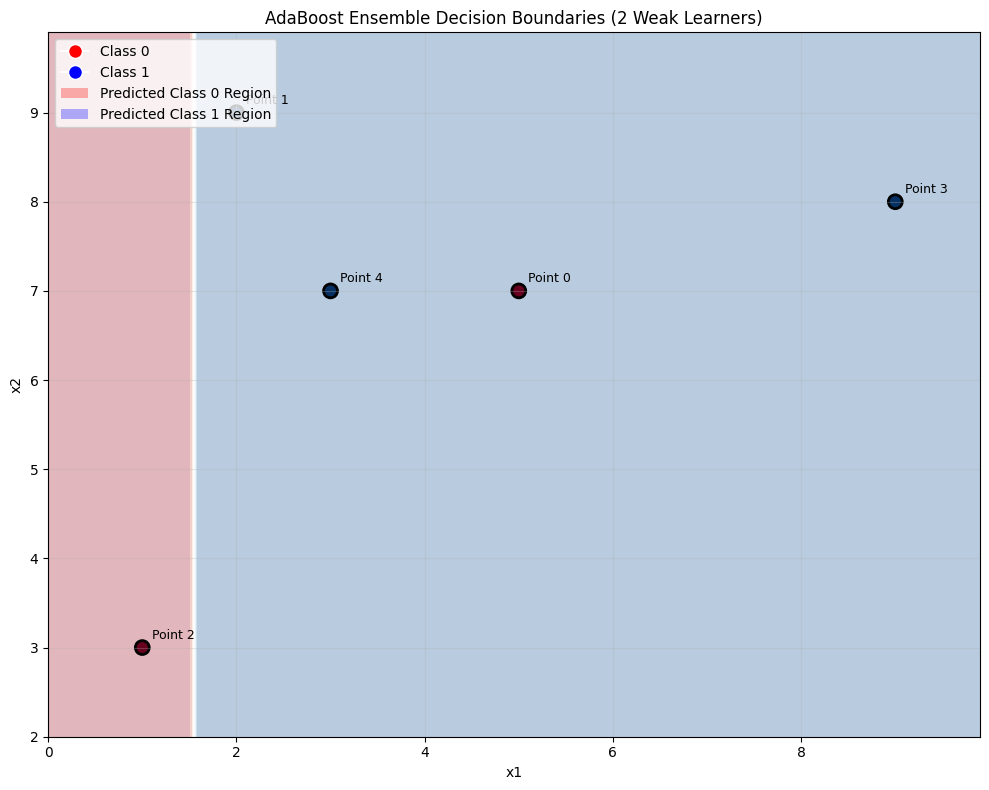

In [24]:
# Create a mesh grid for visualization
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Get predictions from each weak learner on mesh grid
Z1 = dtr1.predict(np.c_[xx.ravel(), yy.ravel()])
Z2 = dtr2.predict(np.c_[xx.ravel(), yy.ravel()])

# Transform predictions for weighted combination
Z1_transformed = 2 * Z1 - 1
Z2_transformed = 2 * Z2 - 1

# Combine predictions using learned alphas
Z_weighted = alpha1 * Z1_transformed + alpha2 * Z2_transformed
Z_ensemble = (Z_weighted > 0).astype(int)

# Reshape for plotting
Z_ensemble = Z_ensemble.reshape(xx.shape)

# Plot ensemble decision boundaries
plt.figure(figsize=(10, 8))

# Plot decision regions
plt.contourf(xx, yy, Z_ensemble, alpha=0.3, cmap='RdBu_r')

# Plot data points
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, s=100, 
                      edgecolors='black', linewidth=2, 
                      cmap='RdBu_r')

# Add legend and labels
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('AdaBoost Ensemble Decision Boundaries (2 Weak Learners)')

# Add point labels
for i, (x, y_val) in enumerate(zip(X[:, 0], X[:, 1])):
    plt.text(x + 0.1, y_val + 0.1, f'Point {i}', fontsize=9)

# Create custom legend for classification
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', 
           markersize=10, label='Class 0'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', 
           markersize=10, label='Class 1'),
    plt.Rectangle((0, 0), 1, 1, fc='red', alpha=0.3, label='Predicted Class 0 Region'),
    plt.Rectangle((0, 0), 1, 1, fc='blue', alpha=0.3, label='Predicted Class 1 Region')
]
plt.legend(handles=legend_elements, loc='upper left')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 25: Continue the Process for More Iterations

The AdaBoost algorithm typically continues for a predetermined number of iterations or until a stopping criterion is met. Here's a summary of the process we would repeat:

1. **Sample** new dataset based on current weights
2. **Train** a new weak learner on the sampled data
3. **Calculate** its weighted error and alpha value
4. **Update** weights based on its performance
5. **Combine** all weak learners' predictions using weighted voting

The complete AdaBoost algorithm formula:

**Final Prediction** = sign( Σ [α_t * h_t(x)] )
where:
- α_t = 0.5 * ln((1 - ε_t) / ε_t) is the weight of weak learner t
- h_t(x) is the prediction of weak learner t (converted to ±1)
- ε_t is the weighted error rate of weak learner t

In [25]:
# Summary of what we've accomplished
print("=" * 60)
print("ADA BOOST IMPLEMENTATION SUMMARY")
print("=" * 60)
print(f"\n1. Dataset: {len(df)} points, 2 features, binary classification")
print(f"2. Initial weights: Equal distribution (1/{len(df)} each)")
print(f"\n3. First Weak Learner (Decision Tree Stump):")
print(f"   - Alpha (weight): {alpha1:.4f}")
print(f"   - Misclassified: Point {df[df['y'] != df['y_pred']].index.tolist()}")
print(f"   - Accuracy: {accuracy_dtr1:.2%}")

print(f"\n4. Second Weak Learner (Decision Tree Stump):")
print(f"   - Alpha (weight): {alpha2:.4f}")
print(f"   - Misclassified: Point {df[df['y'] != df['y_pred2']].index.tolist()}")
print(f"   - Accuracy: {accuracy_dtr2:.2%}")

print(f"\n5. AdaBoost Ensemble Results:")
print(f"   - Ensemble Accuracy: {accuracy_ensemble:.2%}")
print(f"   - Misclassified: Point {df[df['y'] != df['final_pred']].index.tolist()}")
print(f"   - Total model weight (|α1| + |α2|): {abs(alpha1) + abs(alpha2):.4f}")

print("\n" + "=" * 60)
print("NEXT STEPS (if continuing):")
print("1. Sample new dataset using weights from iteration 2")
print("2. Train third weak learner on sampled data")
print("3. Calculate α3 based on weighted error")
print("4. Update weights again")
print("5. Combine predictions: sign(α1*h1 + α2*h2 + α3*h3)")
print("=" * 60)

ADA BOOST IMPLEMENTATION SUMMARY

1. Dataset: 5 points, 2 features, binary classification
2. Initial weights: Equal distribution (1/5 each)

3. First Weak Learner (Decision Tree Stump):
   - Alpha (weight): 0.6931
   - Misclassified: Point [4]
   - Accuracy: 80.00%

4. Second Weak Learner (Decision Tree Stump):
   - Alpha (weight): 0.9730
   - Misclassified: Point [0]
   - Accuracy: 80.00%

5. AdaBoost Ensemble Results:
   - Ensemble Accuracy: 80.00%
   - Misclassified: Point [0]
   - Total model weight (|α1| + |α2|): 1.6661

NEXT STEPS (if continuing):
1. Sample new dataset using weights from iteration 2
2. Train third weak learner on sampled data
3. Calculate α3 based on weighted error
4. Update weights again
5. Combine predictions: sign(α1*h1 + α2*h2 + α3*h3)


## Conclusion

This completes two full iterations of the AdaBoost algorithm. The key insight is that AdaBoost:
1. Starts with equal weights for all samples
2. Sequentially trains weak learners, each focusing on previously misclassified examples
3. Weighs each learner's vote by its accuracy (via α values)
4. Combines them into a strong ensemble classifier

The process can be repeated for more iterations until a desired accuracy is achieved or a maximum number of learners is reached.